# Guide3D: a first study on acquired fluoroscopic images

This companion notebook recomputes the **tables and figures from the committed pilot results**. It does not download Guide3D or rerun image processing. Its only numerical and plotting dependencies are NumPy and Matplotlib.

The study evaluates two-dimensional guidewire enhancement on a vascular phantom. It is not clinical validation or a reproduction of the private MICCAI 2012 experiment. See the [study report](../docs/benchmarks/guide3d/README.md) for the protocol and image-processing reproduction command.

## Goal

Compare polygonal path image (PPI) voting against raw darkness and local dark contrast on held-out **whole acquisitions**. Check whether any gain in annotated-centerline coverage comes with more off-reference selections, and expose acquisition-level variation.

The visible annotations describe the full tip and shaft. The study contains no guidewire-absence controls, and makes no three-dimensional reconstruction claim.

## Setup

Open this notebook from a checkout of the repository. To reproduce its saved outputs:

```bash
python -m pip install numpy 'matplotlib>=3.8' jupyterlab
jupyter lab examples/ppi_guide3d_study.ipynb
```

The committed input is `docs/benchmarks/guide3d/results.json`. Raw Guide3D images and annotations remain external to this repository; every figure below uses derived scalar measurements only.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "benchmarks").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "benchmarks" / "plot_guide3d.py").is_file():
    raise RuntimeError("Open this notebook from the repository root or its examples directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from benchmarks.plot_guide3d import (
    load_results,
    macro_summary,
    method_label,
    methods_in,
    plot_acquisitions,
    plot_budget_curves,
    plot_localization,
    plot_precision,
    set_style,
)

set_style()
report = load_results(ROOT / "docs/benchmarks/guide3d/results.json")
rows = report["evaluation"]["rows"]
primary_budget = report["protocol"]["primary_budget"]
native_scale = report["protocol"]["native_pixels_per_working_pixel"]
selected_method = report["selection"]["selected_method"]
methods = methods_in(rows)

## Context and methods

The pilot samples ten evenly spaced paired frames per acquisition and keeps both camera views together. Three acquisitions form the development set; ten whole acquisitions are held out. The sole fluid/straight acquisition appears only in evaluation.

Images are averaged from 1024×1024 to 512×512. The image-derived field of view is eroded by 16 working pixels for evaluation. PPI operates on the image without an annotation-derived crop. The local baseline and local-input PPI receive the same quantized Gaussian-background contrast. A small PPI parameter comparison uses development acquisitions only; the selected configuration is carried to evaluation alongside the unchanged default.

### Metric assumptions

- **Coverage:** fraction of reference arclength inside the ROI within two working pixels (four native pixels) of a selected pixel center.
- **Selected-pixel precision:** fraction of selected pixels within that tolerance of the finite annotated polyline.
- **Off-reference rate:** selected pixels outside the tolerance tube, divided by all ROI pixels outside the tube. Other visible structures may be unannotated; this is not an anatomical error diagnosis.
- **Area budgets:** nominal ROI fractions of 0.25%, 0.5%, 1% and 2%. Complete cutoff tie blocks are retained, so actual selected area can exceed the nominal budget.
- **Aggregation:** first average selected views within each acquisition, then give each acquisition equal weight. Ranges show observed acquisition means, not confidence intervals. The acquisitions share the phantom and imaging setup; disjoint groups do not establish statistical independence. Coverage and precision have different populations and are not combined into an F1 score.

### 1. Check the split and operating points

The loader rejects duplicated case/method/budget rows, unequal method populations and overlapping development/evaluation acquisitions. The table below is derived from the result rows rather than the advertised dataset size.

In [3]:
lines = [
    "| Split | Acquisitions | Paired frames | 2D views | Measurement rows |",
    "|---|---:|---:|---:|---:|",
]
for split in ("development", "evaluation"):
    split_rows = report[split]["rows"]
    acquisitions = {r["acquisition_id"] for r in split_rows}
    pairs = {(r["acquisition_id"], r["frame_number"]) for r in split_rows}
    views = {r["case_id"] for r in split_rows}
    lines.append(
        f"| {split.title()} | {len(acquisitions)} | {len(pairs)} | "
        f"{len(views)} | {len(split_rows):,} |"
    )
display(Markdown("\n".join(lines)))
assert np.isclose(primary_budget, 0.01)
assert np.isclose(native_scale, 2)
assert selected_method in methods
assert all(
    np.isclose(row["selection"]["actual_fraction"], row["metrics"]["selected_fraction"])
    for row in rows
)
print("Split, row-grain and area-fraction checks passed.")

| Split | Acquisitions | Paired frames | 2D views | Measurement rows |
|---|---:|---:|---:|---:|
| Development | 3 | 30 | 60 | 1,440 |
| Evaluation | 10 | 100 | 200 | 4,000 |

Split, row-grain and area-fraction checks passed.


In [4]:
audit = report["audit"]
assert audit["archive_integrity_verified"]
assert not audit["missing_images"]
display(
    Markdown(
        f"The audited archive contains **{audit['image_count']:,} images**. "
        f"The pinned annotation file covers **{audit['annotated_image_count']:,} views "
        f"in {audit['annotated_acquisition_count']} acquisitions**. "
        "These downloaded-source counts differ from the original project's advertised total; "
        "the pilot uses the verified annotated subset."
    )
)

The audited archive contains **8,742 images**. The pinned annotation file covers **8,200 views in 13 acquisitions**. These downloaded-source counts differ from the original project's advertised total; the pilot uses the verified annotated subset.

### 2. Read the development selection

These are development scores, not held-out performance. The predeclared objective is acquisition-average coverage at the nominal 1% budget; exact ties favor smaller actual selected area, then configuration order.

In [5]:
lines = [
    "| Local-input PPI candidate | Coverage (%) | Actual selected area (%) | Selected |",
    "|---|---:|---:|:---:|",
]
for candidate in report["selection"]["development_scores"]:
    chosen = "yes" if candidate["method"] == selected_method else ""
    lines.append(
        f"| {method_label(candidate['method'])} | {100 * candidate['coverage']:.2f} | "
        f"{100 * candidate['actual_fraction']:.3f} | {chosen} |"
    )
display(Markdown("\n".join(lines)))

| Local-input PPI candidate | Coverage (%) | Actual selected area (%) | Selected |
|---|---:|---:|:---:|
| PPI · local default | 69.72 | 1.027 |  |
| PPI · local relaxed | 87.03 | 1.005 | yes |
| PPI · local short | 56.15 | 1.021 |  |

## Results

### 3. Compare held-out measurements at the primary area budget

The primary operating point is **1% nominal ROI area**. Actual area is printed alongside quality measurements because ties can change the amount selected. All measurements below are means of acquisition means; the two intensity baselines are separate comparators.

In [6]:
summary = {}
lines = [
    "| Method | Coverage (%) | Precision (%) | Off-reference rate (%) | Actual area (%) |",
    "|---|---:|---:|---:|---:|",
]
for method in methods:
    stats = {
        metric: macro_summary(rows, method, metric, primary_budget)
        for metric in (
            "centerline_coverage",
            "selected_pixel_precision",
            "off_tube_false_positive_rate",
            "actual_fraction",
        )
    }
    summary[method] = stats
    if any(s["valid_acquisitions"] != s["total_acquisitions"] for s in stats.values()):
        raise ValueError(
            f"Incomplete acquisition metrics for {method}; inspect missing values before summarizing."
        )
    values = [100 * stats[key]["mean"] for key in stats]
    marker = " (development choice)" if method == selected_method else ""
    lines.append(
        f"| {method_label(method)}{marker} | {values[0]:.2f} | {values[1]:.2f} | "
        f"{values[2]:.3f} | {values[3]:.3f} |"
    )
display(Markdown("\n".join(lines)))

| Method | Coverage (%) | Precision (%) | Off-reference rate (%) | Actual area (%) |
|---|---:|---:|---:|---:|
| Raw darkness | 42.82 | 8.80 | 1.071 | 1.167 |
| Local contrast | 83.27 | 19.96 | 0.815 | 1.012 |
| PPI · raw default | 68.84 | 12.43 | 0.913 | 1.035 |
| PPI · local default | 69.75 | 13.60 | 0.893 | 1.027 |
| PPI · local relaxed (development choice) | 89.14 | 17.29 | 0.837 | 1.005 |

In [7]:
chosen_coverage = summary[selected_method]["centerline_coverage"]["mean"]
local_coverage = summary["local_contrast"]["centerline_coverage"]["mean"]
chosen_precision = summary[selected_method]["selected_pixel_precision"]["mean"]
local_precision = summary["local_contrast"]["selected_pixel_precision"]["mean"]
display(
    Markdown(
        f"The development-selected PPI configuration has **{100 * chosen_coverage:.2f}% coverage** "
        f"versus **{100 * local_coverage:.2f}%** for direct local contrast "
        f"({100 * (chosen_coverage - local_coverage):+.2f} percentage points). "
        f"Selected-pixel precision is **{100 * chosen_precision:.2f}%** versus "
        f"**{100 * local_precision:.2f}%**. These comparisons describe this held-out phantom pilot; "
        "the area column and operating-point curves are part of their interpretation."
    )
)

The development-selected PPI configuration has **89.14% coverage** versus **83.27%** for direct local contrast (+5.87 percentage points). Selected-pixel precision is **17.29%** versus **19.96%**. These comparisons describe this held-out phantom pilot; the area column and operating-point curves are part of their interpretation.

### 4. Inspect the area–coverage tradeoff

The horizontal coordinate is the **actual selected area**, averaged using the same acquisition weights as coverage. Each point comes from a declared area budget. Ringed points identify the primary 1% nominal budget.

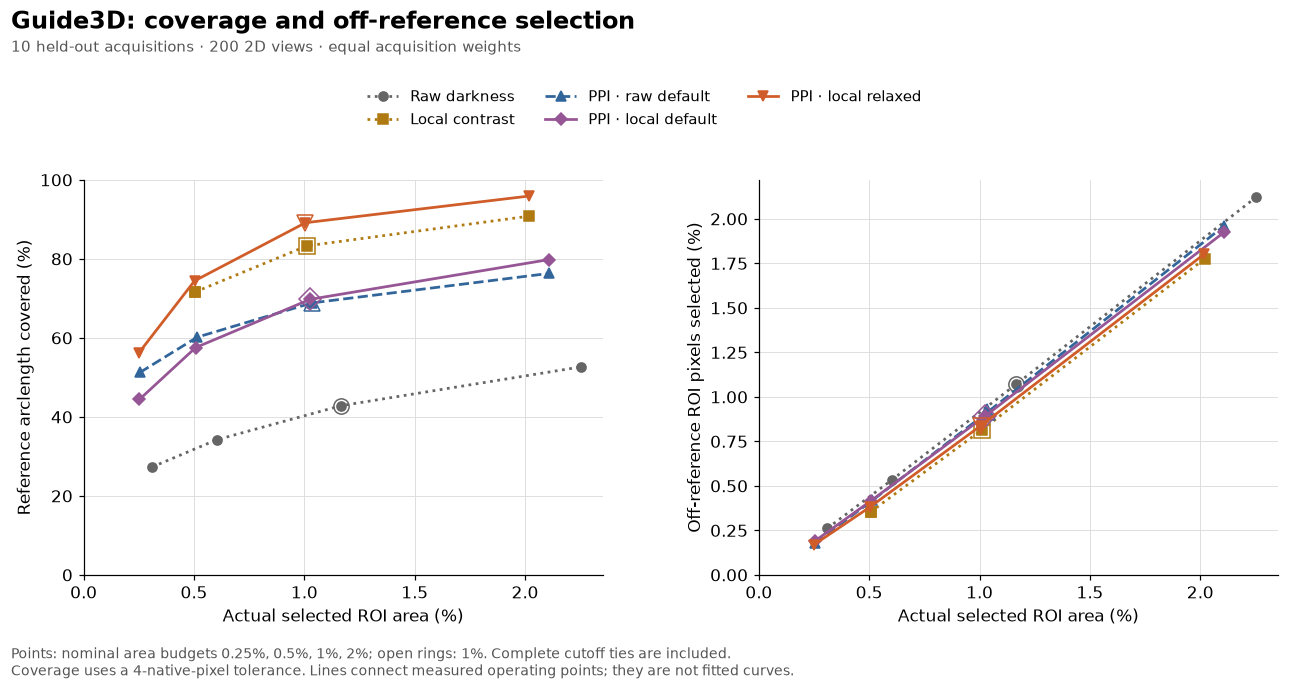

In [8]:
figure = plot_budget_curves(report)
plt.show()

### 5. Check variation between acquisitions

Every cell is a mean across ten paired frames, or twenty 2D views. Comparing methods within each row keeps the acquisition fixed. A high overall average does not imply consistent performance across acquisitions or either guidewire type.

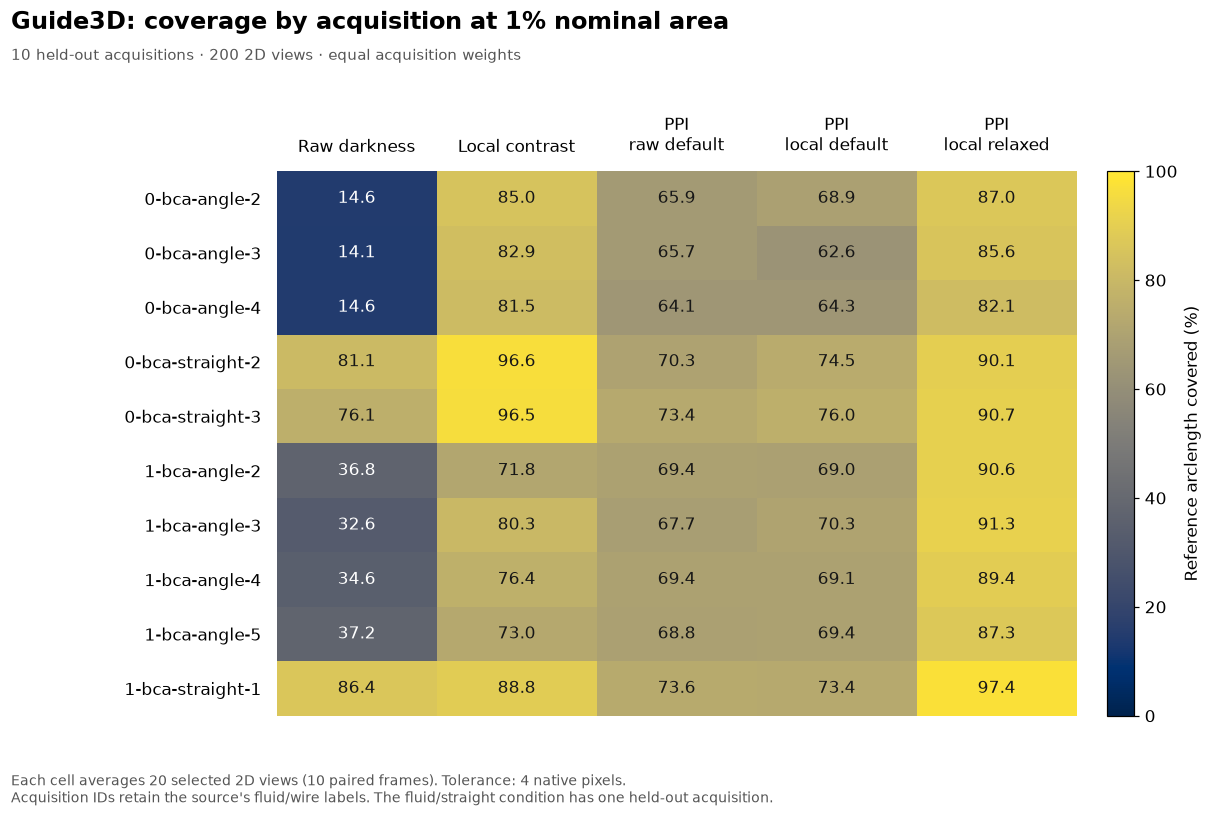

In [9]:
figure = plot_acquisitions(report)
plt.show()

### 6. Keep the selection denominators explicit

Precision asks what fraction of the selected pixels lies near the reference. Off-reference rate asks what fraction of all eligible pixels away from the reference was selected. They are complementary measurements with different denominators. Horizontal lines below span the observed acquisition means; they do not estimate statistical confidence.

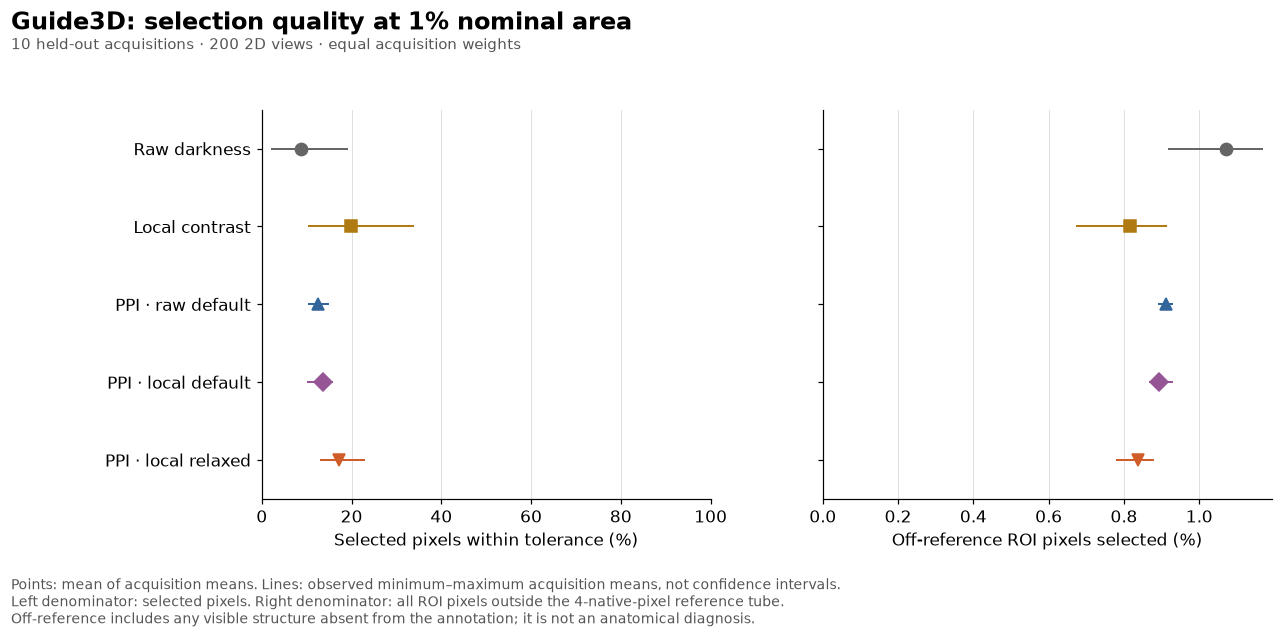

In [10]:
figure = plot_precision(report)
plt.show()

### 7. Measure localization and the evaluated reference fraction

Reference-to-selection distance measures gaps in recovery; selection-to-reference distance measures how far selected pixels wander from the annotation. Distances are expressed in **native pixels**, not millimetres. The chart shows mean distances; per-frame P95 values remain available in the result JSON and are not presented as a pooled P95.

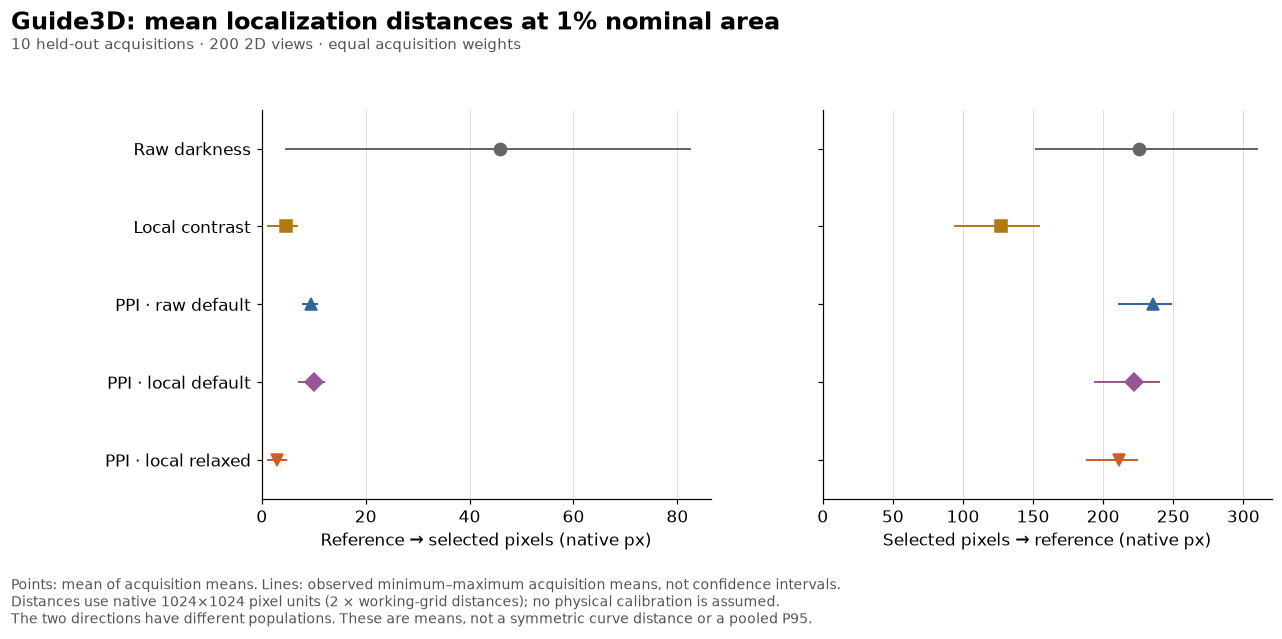

The ROI retains **95.66%** of annotated arclength on average across acquisitions (acquisition means: 95.24–96.31%). Excluded reference samples are not counted as recovered or missed. The retained fraction uses trapezoidal arclength-sample weights, not exact segment clipping.

In [11]:
figure = plot_localization(report)
plt.show()
reference_fraction = macro_summary(rows, "darkness", "reference_length_fraction", primary_budget)
display(
    Markdown(
        f"The ROI retains **{100 * reference_fraction['mean']:.2f}%** of annotated arclength "
        f"on average across acquisitions (acquisition means: "
        f"{100 * reference_fraction['minimum']:.2f}–{100 * reference_fraction['maximum']:.2f}%). "
        "Excluded reference samples are not counted as recovered or missed. The retained fraction "
        "uses trapezoidal arclength-sample weights, not exact segment clipping."
    )
)

## Checks and provenance

Scalar bounds and metric numerator/denominator identities are checked below. These checks verify the published measurements' internal consistency; the study runner separately records input hashes, source hashes and the frozen protocol. The image preprocessing and annotation overlays were inspected during study construction; this scalar-only notebook does not repeat that image audit.

In [12]:
for split in ("development", "evaluation"):
    for row in report[split]["rows"]:
        metric = row["metrics"]
        assert (
            metric["true_positive_pixels"] + metric["false_positive_pixels"]
            == metric["selected_pixels"]
        )
        assert metric["selected_pixels"] <= metric["roi_pixels"]
        for key in (
            "centerline_coverage",
            "selected_pixel_precision",
            "off_tube_false_positive_rate",
            "selected_fraction",
            "reference_length_fraction",
        ):
            value = metric[key]
            assert value is None or 0 <= value <= 1 + 1e-12
        if metric["off_tube_pixels"]:
            assert np.isclose(
                metric["off_tube_false_positive_rate"],
                metric["false_positive_pixels"] / metric["off_tube_pixels"],
            )
print("All scalar range and count checks passed.")
print("Study:", report["protocol"]["study_id"])
print("Protocol frozen:", report["protocol_freeze"]["frozen_at_utc"])
print("Annotation SHA256:", report["protocol"]["sources"]["annotation_sha256"])
print("Image archive SHA256:", report["protocol"]["sources"]["archive_sha256"])

All scalar range and count checks passed.
Study: guide3d-pilot-v1
Protocol frozen: 2026-09-26T11:42:17.809977+00:00
Annotation SHA256: 5b6fa440c15ca66da276fe3619cd9122e5ab8d2ca662768c737e141991abdfc3
Image archive SHA256: 90adb69e69ff8ec128130da33d390cd9b23c51e122d092229c549b1f33d3c236


## Next steps

Use the acquisition-level comparisons to identify reproducible limitations before altering the algorithm or defaults. A larger study should include additional acquisitions, difficult backgrounds, and explicit guidewire-absence controls. Human clinical data and body-specific annotations would answer different questions and need separate validation.

The original MICCAI 2012 dataset was private. This publicly reproducible phantom study is a new evaluation, not a reconstruction of that experiment.

### Sources and data terms

Guide3D: Tudor Jianu et al., *Guide3D: A Bi-planar X-ray Dataset for 3D Shape Reconstruction*, 2024. [Paper](https://arxiv.org/abs/2410.22224) · [Project](https://airvlab.github.io/guide3d/) · [Dataset](https://huggingface.co/datasets/airvlab/guide3d).

The upstream dataset is identified as [CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/). Downloaded images and annotations are not bundled with the package. The figures in this notebook contain derived scalar results, with the dataset and frozen protocol identified above.